[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1Nbv2NjDSYvdXLCMGQUycg0z_rOH5ey4V?usp=sharing)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/rajatbikramkarki/email-spam-detection-machine-learning-algorithms)

# CSC266 - Artificial Intelligence

## Spam Email Detection

### Project: Email Spam Detection

**Author:** Rajat Bikram Karki (Machine Learning Focus)

**Group Members:** Samip Khadka (Deep Learning Focus), Mandeep Kumar Chaudhary (Documentation & Presentation)

**Abstract:** This notebook constitutes the Machine Learning component of the Email Spam Detection project. It explores the application of classical machine learning algorithms—specifically Random Forest, K-Nearest Neighbors (KNN), Decision Tree, and Naive Bayes—to classify email messages as Spam or Not Spam. The pipeline includes data loading, data preprocessing, text feature extraction, model training, and evaluation using accuracy, classification reports, and other relevant metrics. The performance of the implemented machine learning models is compared to determine their effectiveness for email spam detection. This notebook represents the Machine Learning component of the overall project, while the Deep Learning component is developed separately using TensorFlow/Keras.

Flowchart for building a machine learning model

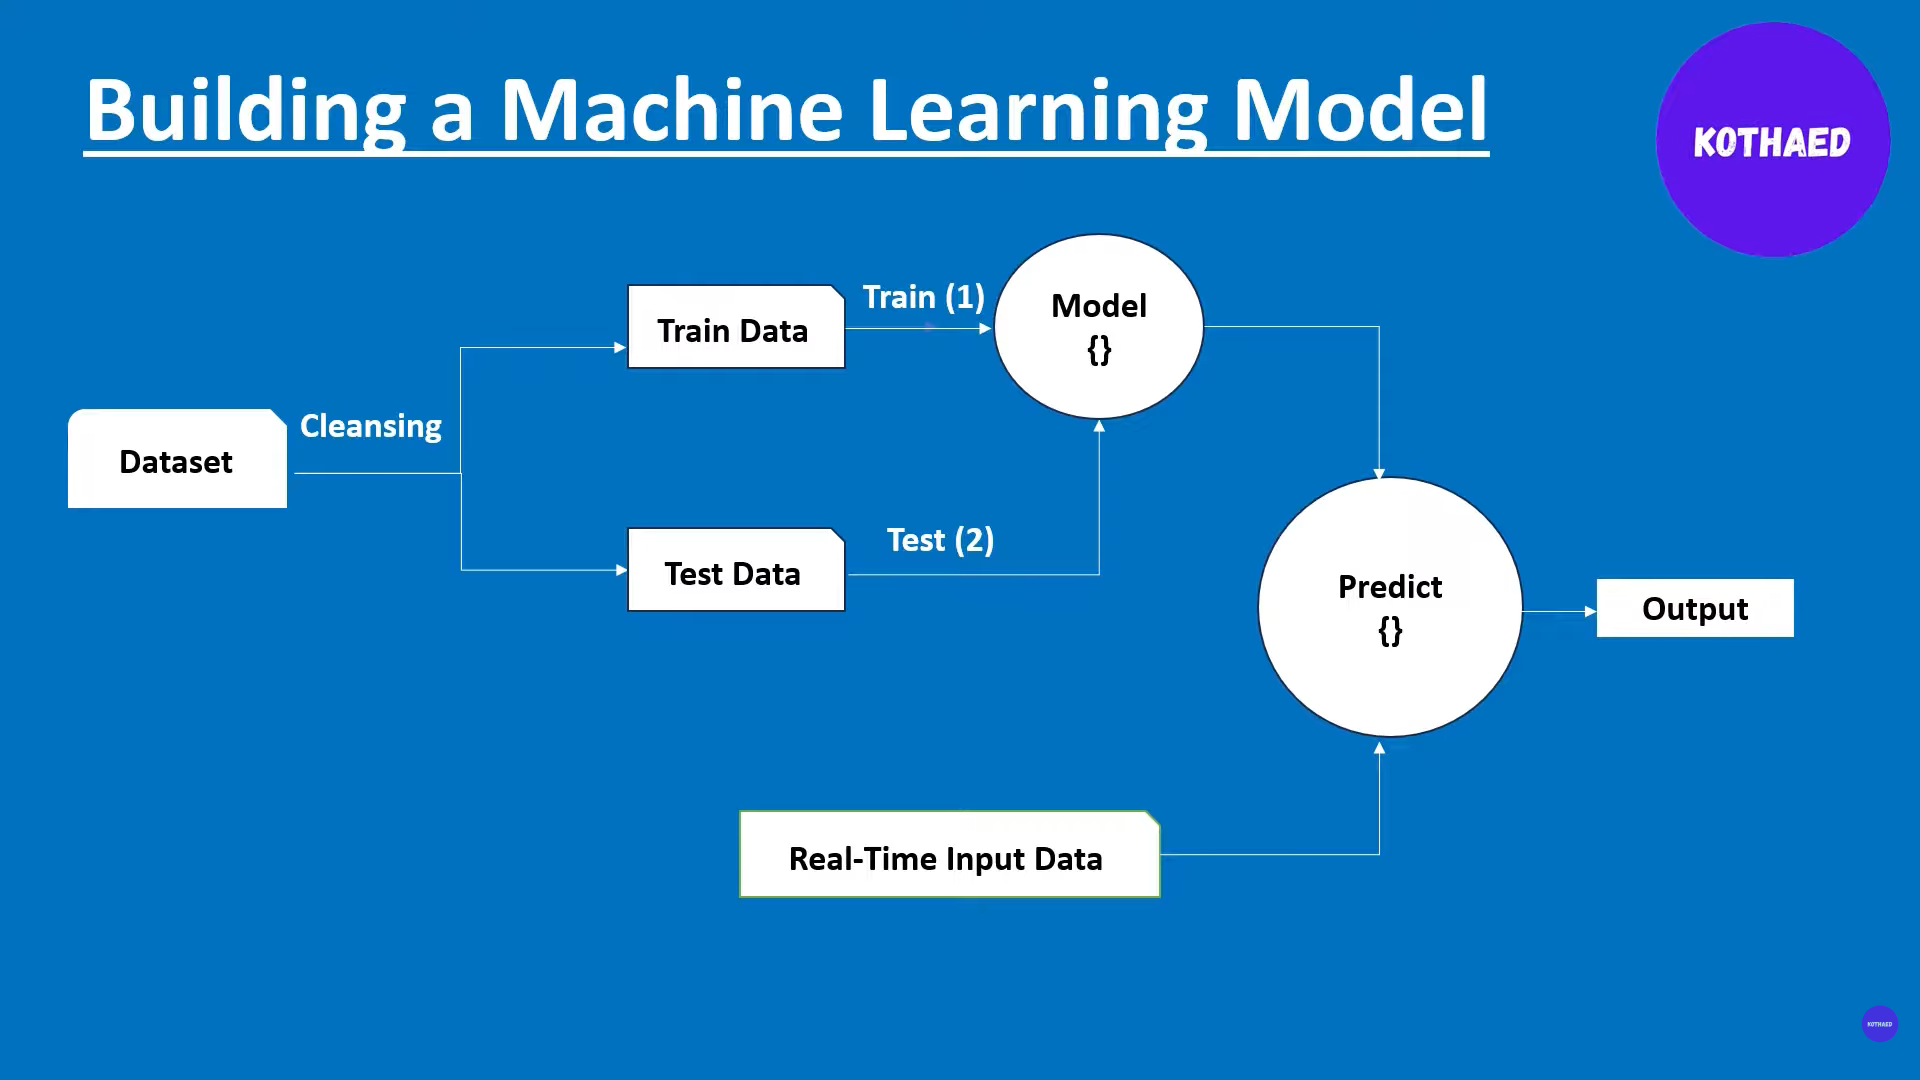

- Cleansing State
    
    Split the dataset into two parts:  80 percent to train the model and 20 percent to test the model ie if the model is working correctly or not
    
- Building the model
    - use Algorithm such as: Naive Bayes, Random Forest, K-Nearest Neighbors, Decision Tree
    - 80% data to train the algorithm
    - 20% data to check the precision of algorithm; precision is above 70 percent deploy it to production

Coding:

## 1. Import dependencies


In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.



Now we import dependencies we use. Here,

| Import | What it does |
| :--- | :--- |
| **`pandas`** | Used to load, clean, and analyze your dataset. For example, reading a CSV file with `pd.read_csv()`. |
| **`matplotlib.pyplot`** | Used to create graphs and charts to visualize your data and results. |
| **`seaborn`** | A visualization library built on Matplotlib. Makes graphs like heatmaps and statistical plots easier. |
| **`train_test_split`** | Splits your dataset into **training data** (used to teach the model) and **testing data** (used to evaluate it). |
| **`CountVectorizer`** | Converts text/email messages into numbers by counting how often words appear. ML models need numerical data. |
| **`MultinomialNB`** | A **Naive Bayes** machine-learning algorithm. It's especially good for text classification, such as spam vs. not spam. |
| **`RandomForestClassifier`** | A machine-learning algorithm that combines many decision trees to make a prediction. |
| **`confusion_matrix`** | Shows how many predictions were correct and where the model made mistakes, such as spam predicted as not spam. |
| **`ConfusionMatrixDisplay`** | Turns the confusion matrix into a visual/graph so it's easier to understand. |
| **`KNeighborsClassifier`** | Classifies something based on the most similar examples around it. For example, emails similar to known spam emails may be classified as spam. |
| **`DecisionTreeClassifier`** | Uses a series of questions/conditions to make a prediction, similar to a flowchart. |



## 2. Clean the data

In [123]:
df = pd.read_csv("/kaggle/input/datasets/venky73/spam-mails-dataset/spam_ham_dataset.csv")
# print(df.head()) -> checks the data
print(df.shape) #gives dimensions of data


(5171, 4)



Our dataset’s dimensions are **[5171 rows x 4 columns].** 

Here Rows contain the data whereas, Column's: 

| Column | Description |
| --- | --- |
| `Unnamed: 0` | Original row/index identifier from the dataset |
| `label` | Email classification — `ham` or `spam` |
| `text` | The actual email/message content |
| `label_num` | Numerical version of the label — `0` = ham, `1` = spam |

Now check for duplicates in the dataset


In [124]:
df.drop_duplicates(inplace=True)
print(df.shape)
print(df.isnull().sum())


(5171, 4)
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64



Result:

| Column | Null values |
| --- | --- |
| `Unnamed: 0` | 0 |
| `label` | 0 |
| `text` | 0 |
| `label_num` | 0 |
| **Total** | **0** |

As our first column is “`Unnamed: 0`" we will be changing it to “`Index`”


In [125]:
df.rename(columns={'Unnamed: 0': 'index'}, inplace=True)
print(df.columns)


Index(['index', 'label', 'text', 'label_num'], dtype='object')


Result:

In [126]:
['index', 'label', 'text', 'label_num']


['index', 'label', 'text', 'label_num']


Since our dataset is already clean ie no duplicates and null values this process can be skipped.

## 3. Visualizing Data

Visualizing if the data is spam or not spam


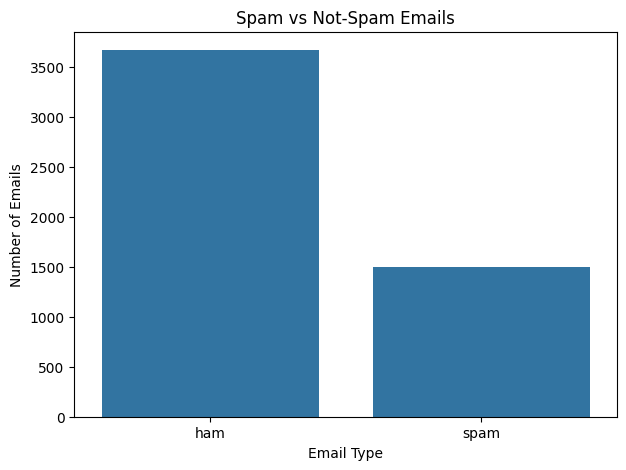

In [127]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='label')

plt.title("Spam vs Not-Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

plt.show()



In form of pie chart:


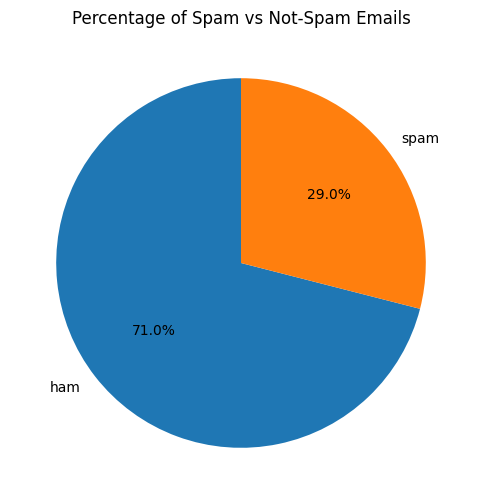

In [128]:

label_counts = df['label'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage of Spam vs Not-Spam Emails")

plt.show()



Finding email length to visualize it:


In [129]:
df['email_length'] = df['text'].apply(len)

print("\nEmail Length Statistics:")
print(df['email_length'].describe())



Email Length Statistics:
count     5171.000000
mean      1048.391994
std       1528.513435
min         11.000000
25%        244.000000
50%        540.000000
75%       1237.000000
max      32258.000000
Name: email_length, dtype: float64



Visualizing email length:


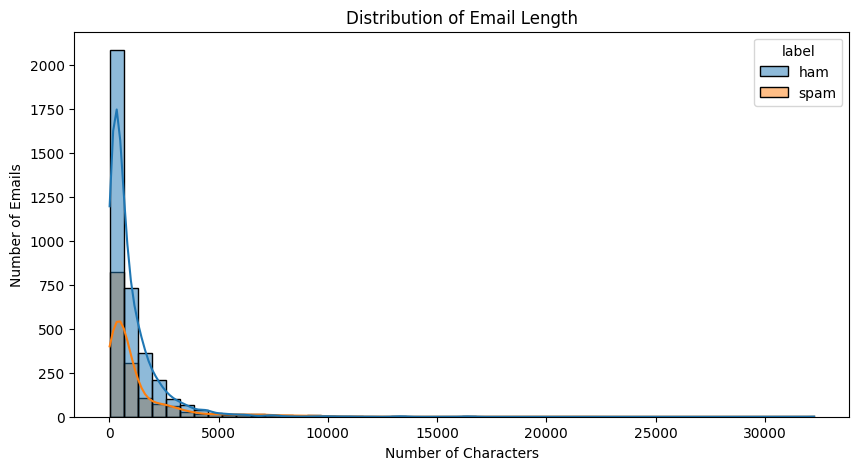

In [130]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='email_length',
    hue='label',
    bins=50,
    kde=True
)

plt.title("Distribution of Email Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Emails")

plt.show()



Comparing average email length


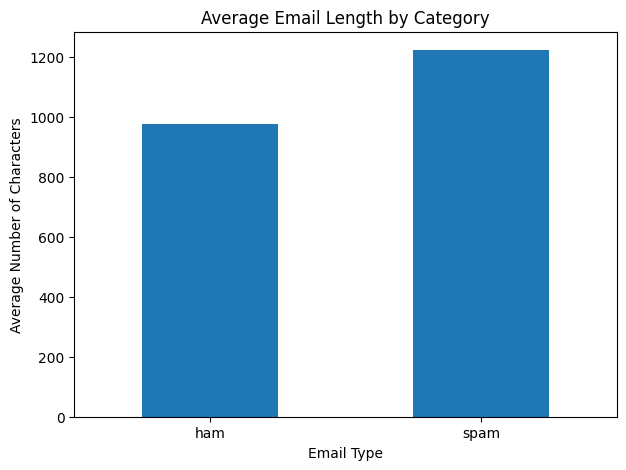

In [131]:
average_length = df.groupby('label')['email_length'].mean()

plt.figure(figsize=(7, 5))

average_length.plot(kind='bar')

plt.title("Average Email Length by Category")
plt.xlabel("Email Type")
plt.ylabel("Average Number of Characters")
plt.xticks(rotation=0)

plt.show()



## 4. Building  the Model:

### A) Prerequisites

First, in our dataset the emails are classified as `ham` for not spam emails and `spam` for spam email, we change `ham` to `not spam` for easier use.


In [132]:
df['label']= df['label'].replace({
    'ham' : 'not spam',
    'spam': 'spam'
}
)



Now we split our dataset into two parts 80% for training and 20% for testing


In [133]:
X = df['text']       # Email text → INPUT
Y = df['label_num']  # 0/1 → TARGET

(X_train,X_test,Y_train,Y_test)= train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)



Here,

- **X = input/features**
- **Y = target/output**

Why `stratify=y`?

Our dataset has more **not-spam** emails than spam emails. `stratify=y` makes sure the **same spam/not-spam proportion** is maintained in both training and testing sets.

Simply speaking, `stratify=y` makes data split for training and testing model more proportional.

For example:

Original:
not spam → ~71%
spam     → ~29%

Training:
not spam → ~71%
spam     → ~29%

Testing:
not spam → ~71%
spam     → ~29%

Now we need to turn our email text into decimal values for this we use `CountVectorizer` 

- `CountVectorizer`
    
    `CountVectorizer` is a popular [**Scikit-learn**](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) tool in Python that **converts a collection of text documents into a matrix of token counts**.
    
    ![image.png](attachment:image 1.png)
    
    Example:
    
    Email 1: "hello how are you"
    Email 2: "hello win money"
    
    `CountVectorizer` creates a vocabulary:
    
    ['are', 'hello', 'how', 'money', 'win', 'you']
    
    Then it converts the emails into numbers:
    
    | Email | are | hello | how | money | win | you |
    | --- | --- | --- | --- | --- | --- | --- |
    | Email 1 | 1 | 1 | 1 | 0 | 0 | 1 |
    | Email 2 | 0 | 1 | 0 | 1 | 1 | 0 |
    
    So:
    
    "hello how are you"
    ↓
    [1, 1, 1, 0, 0, 1]
    
    Those numbers can then be given to your ML classifier.
    

Now using `CountVectorizer` :

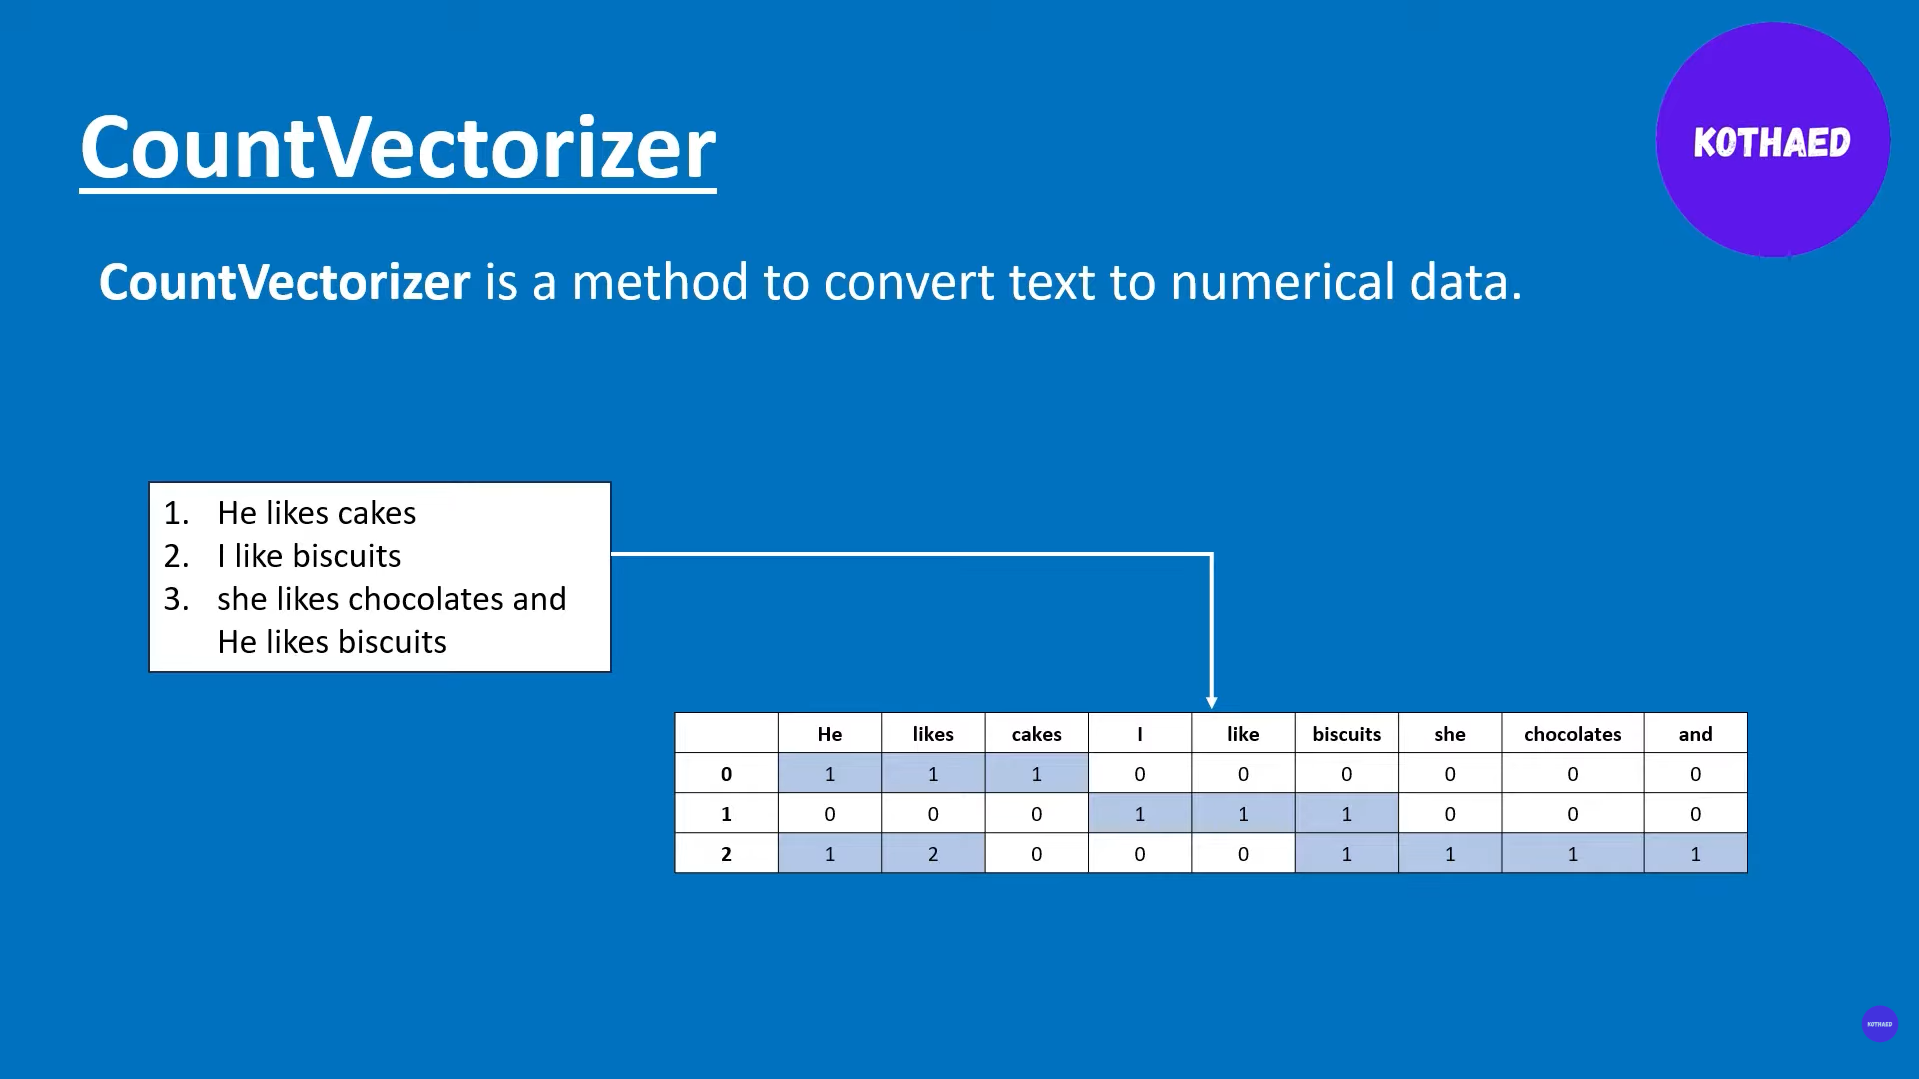

In [134]:
cv = CountVectorizer()
X_train_Vectorized = cv.fit_transform(X_train)



This learns the vocabulary only from our training emails and converts each email into a vector of word counts.

### B) Creating Model According to Algorithms

### 1. Naive Bayes Classifier

#### How Naive Bayes Works

**Naive Bayes Classifier** is a supervised machine learning algorithm used for **classification**. It predicts which category a piece of data belongs to by calculating the probability of each possible category based on the features it contains.

In our project, we use **Multinomial Naive Bayes (`MultinomialNB`)** because our input is text that has been converted into **word counts using `CountVectorizer`**.

The model classifies an email into:

- `0` → Not Spam
- `1` → Spam

Use our vectorized training data and the corresponding labels:


In [135]:
model = MultinomialNB()
model.fit(X_train_Vectorized, Y_train)


MultinomialNB()


This is the actual **training step**.

The model looks at:

X_train_vectorized → word counts
Y_train            → 0 (not spam) / 1 (spam)

It then learns the relationship between the words in an email and its classification.

For example, if words such as **"prize"**, **"winner"**, **"free"**, or **"claim"** frequently appear in spam emails in the training dataset, the model learns that these words can be associated with the **spam** category.

The word **"Naive"** comes from the assumption that the model treats the features (words) as being independent of one another when calculating probabilities. Although this assumption is not completely realistic for natural language, it works surprisingly well for many text-classification problems.

#### A) Testing Model


In [136]:
X_train_vectorized = cv.fit_transform(X_train)
X_test_vectorized= cv.transform(X_test)

print("Training accuracy:", model.score(X_train_vectorized, Y_train))
print("Testing accuracy:", model.score(X_test_vectorized, Y_test))


Training accuracy: 0.9864603481624759
Testing accuracy: 0.9768115942028985



This code simple asks, how well does the model perform on emails it has never seen during training?

Our Accuracy for this model is: 

**Training accuracy**: 0.9864603481624759 \
**Testing accuracy**: 0.9768115942028985

Simply speaking the accuracy of our model is:

|  | Accuracy |
| --- | --- |
| Training | 99% |
| Testing | 97% |



**Confusion Matrix**

In simple terms, a confusion matrix is like a report card for the model's predictions.

It compares:

What the email actually was → Actual value
What the model predicted → Predicted value

For our spam detector:

| Actual | Predicted | Meaning |
| --- | --- | --- |
| Not Spam | Not Spam | ✅ Correct |
| Not Spam | Spam | ❌ Wrong |
| Spam | Not Spam | ❌ Wrong |
| Spam | Spam | ✅ Correct |


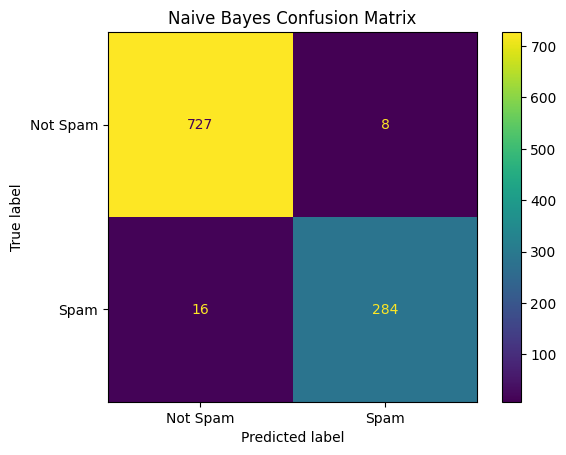

In [137]:
nb_predictions = model.predict(X_test_vectorized)
cm_nb = confusion_matrix(
    Y_test,
    nb_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['Not Spam', 'Spam']
)

disp.plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()

**What are you viewing?**

This graph shows how Naive Bayes classified the test emails.

The graph has:

| | Predicted Not Spam | Predicted Spam |
| :--- | :---: | :---: |
| **Actual Not Spam** | [A] | [B] |
| **Actual Spam** | [C] | [D] |

* Top-left: Emails that were actually Not Spam and correctly predicted as Not Spam.
* Top-right: Emails that were actually Not Spam but predicted as Spam.
* Bottom-left: Emails that were actually Spam but predicted as Not Spam.
* Bottom-right: Emails that were actually Spam and correctly predicted as Spam.

#### B) Predict Data

In a data model, to predict means to use a trained algorithm to estimate an unknown outcome or forecast future events based on historical patterns. The model applies the rules it learned during training to new, unseen data to generate its best educated guess.

In [138]:
new_email = [
    "Congratulations! You have won a free prize. Click here to claim it."
]
new_email_vectorized = cv.transform(new_email)

prediction = model.predict(new_email_vectorized)
print(prediction)


[1]



If we run this code we will get the result as: [1] ie Spam

0 = not spam
1 = spam

So to change it into human readable format we can add:


In [139]:
if prediction == 1:
    result = "spam"
else:
    result = "not spam"

print(f"{result}: {new_email[0]}")

spam: Congratulations! You have won a free prize. Click here to claim it.



Now if we want to use the model to predict for not spam then we can use:


In [140]:
new_email = [
    "Hi John, just wanted to confirm that our meeting is scheduled for tomorrow at 10 AM."
]

new_email_vectorized = cv.transform(new_email)

prediction = model.predict(new_email_vectorized)
print(prediction)


for email, prediction in zip(new_email, prediction):
    if prediction == 1:
        result = "\nspam"
    else:
        result = "\nnot spam"

    print(f"{result}: {email}")



[0]

not spam: Hi John, just wanted to confirm that our meeting is scheduled for tomorrow at 10 AM.



### 2. Random Forest

**Random Forest** is a supervised machine learning classification algorithm that combines the predictions of multiple **Decision Trees** to make a final prediction. Instead of relying on a single decision tree, Random Forest creates many trees and combines their results, which generally makes the model more accurate and less prone to overfitting.

In our spam email detection project, Random Forest is used to classify an email as either:

- **0 → Not Spam**
- **1 → Spam**

#### How Random Forest Works

Random Forest works by creating multiple decision trees using different subsets of the training data and features.

The basic process is:

1. **Create multiple decision trees**
The algorithm builds many decision trees instead of using only one.
2. **Use different training samples**
Each tree is trained using a randomly selected subset of the training data.
3. **Use different features**
Each tree also considers a random subset of available features when making decisions.
4. **Make predictions**
Each decision tree predicts whether an email is spam or not spam.
5. **Majority voting**
For classification, the final prediction is based on the class that receives the most votes from the trees.

For example:

Tree 1 → Spam
Tree 2 → Not Spam
Tree 3 → Spam
Tree 4 → Spam
Tree 5 → Spam

Final Prediction → Spam

#### A) Testing Model


In [141]:
rf = RandomForestClassifier(
    random_state=42
)



Here:

- `RandomForestClassifier()` creates the Random Forest classification model.
- `random_state=42` ensures that the random operations produce reproducible results. This means we can get consistent results when running the code again.

The model is trained using:


In [142]:
rf.fit(
    X_train_vectorized,
    Y_train
)


RandomForestClassifier(random_state=42)


Here:

X_train_vectorized → Numerical representation of email text
Y_train            → Email labels
0 = Not Spam
1 = Spam

After training, we calculate the training and testing accuracy:


In [143]:
rf_train_accuracy = rf.score(
    X_train_vectorized,
    Y_train
)

rf_test_accuracy = rf.score(
    X_test_vectorized,
    Y_test
)



**Training Accuracy**

Training accuracy tells us how well the Random Forest classifies the emails that it was trained on.

**Testing Accuracy**

Testing accuracy tells us how well the model performs on unseen emails that were not used during training.

Testing accuracy is particularly important because it gives us an idea of how well the model can generalize to new emails.


In [144]:
print("Random Forest")
print("Training Accuracy:", rf_train_accuracy)
print("Testing Accuracy:", rf_test_accuracy)


Random Forest
Training Accuracy: 1.0
Testing Accuracy: 0.9806763285024155



**Confusion Matrix**

In simple terms, a confusion matrix is like a report card for the model's predictions.

It compares:

What the email actually was → Actual value
What the model predicted → Predicted value

For our spam detector:

| Actual | Predicted | Meaning |
| --- | --- | --- |
| Not Spam | Not Spam | ✅ Correct |
| Not Spam | Spam | ❌ Wrong |
| Spam | Not Spam | ❌ Wrong |
| Spam | Spam | ✅ Correct |


In [145]:
rf_predictions = rf.predict(X_test_vectorized)

cm_rf = confusion_matrix(
    Y_test,
    rf_predictions
)



Now we visualize it:


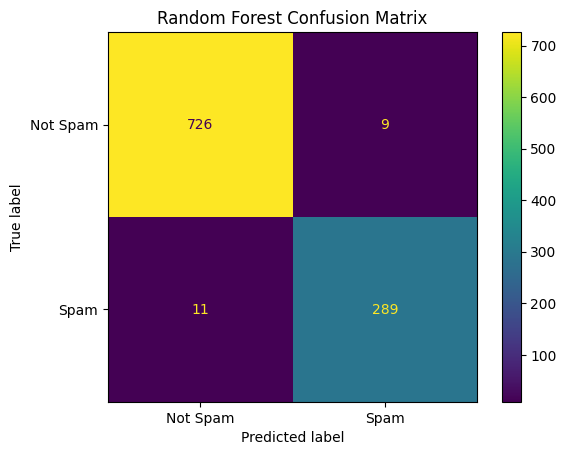

In [146]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not Spam', 'Spam']
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()



#### B) Predict Data

After training, we can use Random Forest to classify new emails.

First, the new emails are converted into numerical features using the **same CountVectorizer**:


In [147]:
new_email = [
    "Hello, my name is Rajat and I wanted to introduce myself. How are you doing?",
    "Hi, how are you?",
    "Can we meet tomorrow?",
    "Congratulations! You have won a $1000 prize!",
    "Claim your free reward now!",
    "You have won a lottery. Click here to claim your prize."
]

new_email_vectorized = cv.transform(new_email)

prediction = rf.predict(new_email_vectorized)



The output of this code will be in 0’s and 1’s. So get human redable result.


In [148]:
for email, prediction_value in zip(new_email, prediction):

    if prediction_value == 1:
        result = "SPAM"
    else:
        result = "NOT SPAM"

    print(f"{result}: {email}")


SPAM: Hello, my name is Rajat and I wanted to introduce myself. How are you doing?
SPAM: Hi, how are you?
SPAM: Can we meet tomorrow?
SPAM: Congratulations! You have won a $1000 prize!
SPAM: Claim your free reward now!
SPAM: You have won a lottery. Click here to claim your prize.



An example of output will be:

"Can we meet tomorrow?" → NOT SPAM

"You have won a lottery. Click here to claim your prize." → SPAM

### 3. K-Nearest Neighbors (KNN)

**K-Nearest Neighbors (KNN)** is a supervised machine learning algorithm used for classification. It classifies a new data point by looking at the **K closest data points** from the training data and choosing the class that appears most often among them.

In our **Spam Email Detection** project, KNN classifies emails into:

- **0 → Not Spam**
- **1 → Spam**

The basic idea is: **emails that are similar to each other are likely to have the same classification.**

#### How KNN Works

KNN works in a simple way:

1. A new email is given to the model.
2. The model finds the **K most similar emails** in the training data.
3. It checks the labels of those nearby emails.
4. The class with the most votes becomes the prediction.

For example, if `K = 5`:

Nearest emails:

Email 1 → Spam
Email 2 → Spam
Email 3 → Not Spam
Email 4 → Spam
Email 5 → Spam

Spam votes     = 4
Not Spam votes = 1

Final prediction → Spam

#### A) Testing Model

We create the KNN model using:


In [149]:
knn = KNeighborsClassifier(
    n_neighbors=5
)



Here, `n_neighbors=5` means that the model looks at the **5 nearest emails** when making a prediction.

The model is trained using:


In [150]:
knn.fit(
    X_train_vectorized,
    Y_train
)


KNeighborsClassifier()


Where:

X_train_vectorized → Numerical representation of email text
Y_train            → 0 (Not Spam) / 1 (Spam)
The email text is converted into numerical values using **CountVectorizer** before being given to KNN. 

After training, we check how accurately KNN classifies the emails:


In [151]:
knn_train_accuracy = knn.score(
    X_train_vectorized,
    Y_train
)

knn_test_accuracy = knn.score(
    X_test_vectorized,
    Y_test
)



The **training accuracy** shows how well KNN performs on the training emails.

The **testing accuracy** shows how well it performs on emails that it has not seen during training.


In [152]:
print("K-NEAREST NEIGHBORS (KNN)")
print("Training accuracy:", knn_train_accuracy)
print("Testing accuracy:", knn_test_accuracy)


K-NEAREST NEIGHBORS (KNN)
Training accuracy: 0.8953094777562862
Testing accuracy: 0.8541062801932368



**Confusion Matrix**

We also use a confusion matrix to see which emails KNN classified correctly or incorrectly:


In [153]:
knn_predictions = knn.predict(X_test_vectorized)

cm_knn = confusion_matrix(
    Y_test,
    knn_predictions
)



In simple terms, the confusion matrix is like a **report card for the predictions**. It compares the actual email category with the category predicted by KNN. 

Now we visualize it:

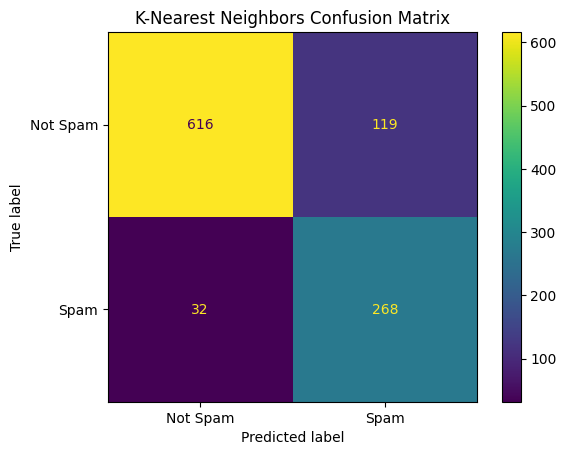

In [154]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['Not Spam', 'Spam']
)

disp.plot()

plt.title("K-Nearest Neighbors Confusion Matrix")
plt.show()

**What are you viewing?**

This graph shows how KNN classified the test emails.<br>
KNN looks at nearby/similar training emails and uses them to decide whether a new email is Spam or Not Spam.

The matrix shows:

| | Predicted Not Spam | Predicted Spam |
| :--- | :---: | :---: |
| **Actual Not Spam** | Correct | Wrong |
| **Actual Spam** | Wrong | Correct |



#### B) Predict Data

First, we create some new emails:


In [155]:
new_email = [
    "Hello, my name is Rajat and I wanted to introduce myself. How are you doing?",
    "Hi, how are you?",
    "Can we meet tomorrow?",
    "Congratulations! You have won a $1000 prize!",
    "Claim your free reward now!",
    "You have won a lottery. Click here to claim your prize."
]



For new emails, we first convert them into numerical form using the same CountVectorizer:


In [156]:
new_email_vectorized = cv.transform(new_email)



Then KNN predicts whether each email is spam or not:


In [157]:
knn_prediction = knn.predict(
    new_email_vectorized
)



The result is:

0 → NOT SPAM
1 → SPAM

Finally, we display the result for each email:


In [158]:
for email, prediction_value in zip(
    new_email,
    knn_prediction
):

    if prediction_value == 1:
        result = "SPAM"
    else:
        result = "NOT SPAM"

    print(f"{result}: {email}")


SPAM: Hello, my name is Rajat and I wanted to introduce myself. How are you doing?
SPAM: Hi, how are you?
SPAM: Can we meet tomorrow?
SPAM: Congratulations! You have won a $1000 prize!
SPAM: Claim your free reward now!
SPAM: You have won a lottery. Click here to claim your prize.



### 4. Decision Tree Classifier

A **Decision Tree Classifier** is a supervised machine learning algorithm used for classification. It makes predictions by asking a series of **yes/no or condition-based questions** about the input data and following a tree-like path until it reaches a final decision.

In our **Spam Email Detection** project, the Decision Tree classifies emails into:

- **0 → Not Spam**
- **1 → Spam**

A simple example is:

Does the email contain "free"?
↓
Yes
↓
Does it contain "prize"?
↓
Yes
↓
SPAM

#### How Decision Tree Works

A Decision Tree is made up of:

- **Root Node** → The first question or condition.
- **Branches** → Possible outcomes of a question.
- **Internal Nodes** → Additional questions used to make a decision.
- **Leaf Nodes** → The final prediction.

The tree keeps asking questions about the features until it reaches a leaf node containing the final classification.

In our project, the original email text is first converted into numerical features using **CountVectorizer**.

#### A) Testing Model

We can create the model using


In [159]:
dt = DecisionTreeClassifier(
    random_state=42
)



Here:

- `DecisionTreeClassifier()` creates the Decision Tree model.
- `random_state=42` ensures reproducible results when the code is run again.

The Decision Tree is trained using:


In [160]:
dt.fit(
    X_train_vectorized,
    Y_train
)


DecisionTreeClassifier(random_state=42)


Here:

X_train_vectorized → Numerical representation of email text
Y_train            → 0 (Not Spam) / 1 (Spam)

After training, we calculate both training and testing accuracy:


In [161]:
dt_train_accuracy = dt.score(
    X_train_vectorized,
    Y_train
)

dt_test_accuracy = dt.score(
    X_test_vectorized,
    Y_test
)



We then display the result using:


In [162]:
print("Decision Tree Classifier")
print("Training Accuracy:", dt_train_accuracy)
print("Testing Accuracy:", dt_test_accuracy)


Decision Tree Classifier
Training Accuracy: 1.0
Testing Accuracy: 0.9314009661835749



**Training Accuracy**

Training accuracy tells us how well the Decision Tree classifies the emails that it learned from.

**Testing Accuracy**

Testing accuracy tells us how well the model classifies emails that it did not see during training.

Testing accuracy is important because it gives us an idea of how well the model can work with new and unseen emails.

**Confusion Matrix**

A confusion matrix is like a report card for the model's predictions.

It compares:

What the email actually was
What the model predicted

| Actual | Predicted | Result |
| --- | --- | --- |
| Not Spam | Not Spam | Correct |
| Not Spam | Spam | Wrong |
| Spam | Not Spam | Wrong |
| Spam | Spam | Correct |

We create the Decision Tree predictions using:


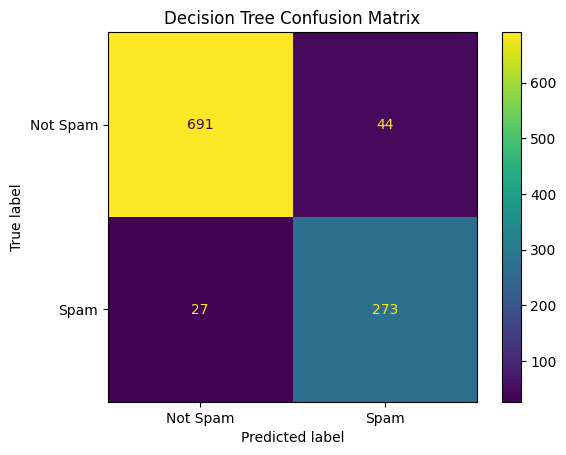

In [163]:
cm_dt = confusion_matrix(
    Y_test,
    dt_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['Not Spam', 'Spam']
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()


This helps us understand not only the accuracy of the model but also **where the model is making mistakes**.

**What are you viewing?**

This graph shows how the Decision Tree classified the test emails.<br>
The Decision Tree makes decisions based on the features of the emails and eventually classifies each email as Spam or Not Spam.

The matrix shows:

| | Predicted Not Spam | Predicted Spam |
| :--- | :---: | :---: |
| **Actual Not Spam** | Correct | Wrong |
| **Actual Spam** | Wrong | Correct |



#### B) Predict Data

After training, we can use the Decision Tree to classify new emails.

First, the new emails are converted into numerical features using the same `CountVectorizer`:


In [164]:
new_email_vectorized = cv.transform(new_email)



Then the Decision Tree makes predictions:


In [165]:
dt_prediction = dt.predict(
    new_email_vectorized
)



The prediction values are:

0 → NOT SPAM
1 → SPAM

The code then displays the result for each new email.



## 5. Model Accuracy Comparison

*In this section, we compare the performance of the four machine learning algorithms used for spam email detection:*

* **Naive Bayes**
* **Random Forest**
* **K-Nearest Neighbors (KNN)**
* **Decision Tree**


### 1. Create Accuracy Comparison

In [166]:
accuracy_df = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Random Forest',
        'K-Nearest Neighbors',
        'Decision Tree'
    ],

    'Training Accuracy': [
        nb_train_accuracy,
        rf_train_accuracy,
        knn_train_accuracy,
        dt_train_accuracy
    ],

    'Testing Accuracy': [
        nb_test_accuracy,
        rf_test_accuracy,
        knn_test_accuracy,
        dt_test_accuracy
    ]
})

display(accuracy_df)

,Model,Training Accuracy,Testing Accuracy
0,Naive Bayes,0.986460,0.976812
1,Random Forest,1.000000,0.980676
2,K-Nearest Neighbors,0.895309,0.854106
3,Decision Tree,1.000000,0.931401


#### 2. Visualize Model Accuracy

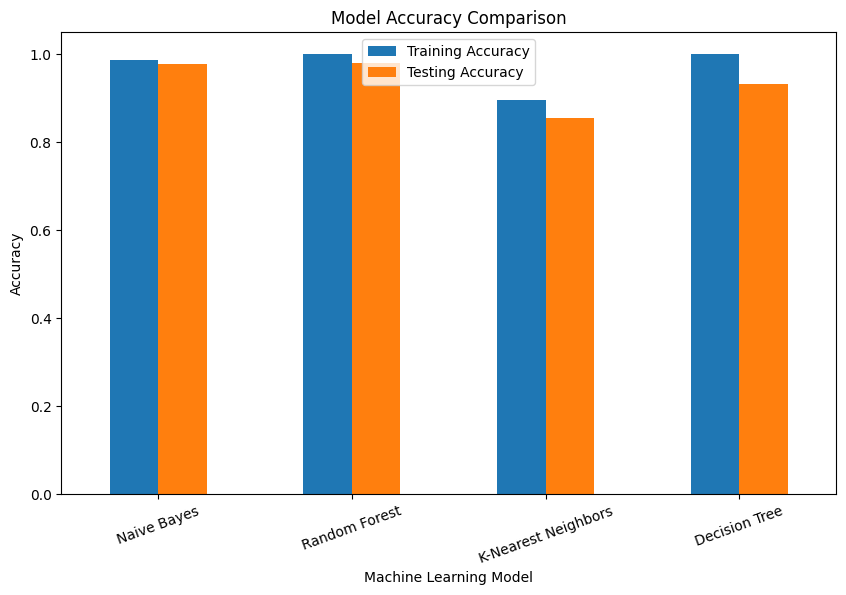

In [167]:
accuracy_plot = accuracy_df.set_index('Model')

accuracy_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.show()

#### Model Accuracy Comparison

The graph above compares the **training accuracy** and **testing accuracy** of four machine learning algorithms used in this project:

* Naive Bayes
* Random Forest
* K-Nearest Neighbors (KNN)
* Decision Tree

The **blue bars** represent the **training accuracy**, while the **orange bars** represent the **testing accuracy**.

Training accuracy shows how well the model performs on the data used during training, whereas testing accuracy shows how well the model performs on unseen emails. Testing accuracy is more important because it reflects the model's ability to generalize to new data.

---

##### Analysis of Each Model

**1. Naive Bayes**

| Metric | Score |
| :--- | :--- |
| **Training Accuracy** | ≈ 99% |
| **Testing Accuracy** | ≈ 98% |

* High training accuracy.
* High testing accuracy.
* Very small difference between training and testing performance.
* Indicates good generalization and low overfitting.

Since spam detection is a text classification problem and Naive Bayes works very well with word frequencies generated by `CountVectorizer`, it performs strongly in this project.

---

**2. Random Forest**

| Metric | Score |
| :--- | :--- |
| **Training Accuracy** | ≈ 100% |
| **Testing Accuracy** | ≈ 98% |

* Perfect training accuracy.
* Very high testing accuracy.
* Slight difference between training and testing accuracy.

This suggests that Random Forest learned the training data extremely well. Although it performs excellently, the perfect training accuracy may indicate a small amount of overfitting.

---

**3. K-Nearest Neighbors (KNN)**

| Metric | Score |
| :--- | :--- |
| **Training Accuracy** | ≈ 89% |
| **Testing Accuracy** | ≈ 85% |

* Lowest training accuracy.
* Lowest testing accuracy.
* Performs worse compared to the other models.

KNN is generally not the best choice for high-dimensional text data because email text converted by `CountVectorizer` produces thousands of features, making distance calculations less effective.

---

**4. Decision Tree**

| Metric | Score |
| :--- | :--- |
| **Training Accuracy** | ≈ 100% |
| **Testing Accuracy** | ≈ 93% |

* Perfect training accuracy.
* Lower testing accuracy than Naive Bayes and Random Forest.
* Larger gap between training and testing accuracy.

This indicates that the Decision Tree is overfitting the training data and does not generalize as well to unseen emails.

---

**Which Model Should Be Used?**

Based on the graph:

| Model         | Testing Accuracy | Observation          |
| ------------- | :--------------: | -------------------- |
| **Naive Bayes**   | ~98%             | Excellent            |
| **Random Forest** | ~98%             | Excellent            |
| **Decision Tree** | ~93%             | Moderate Overfitting |
| **KNN**           | ~85%             | Lowest Performance   |

The final choice is between:

* **Naive Bayes**
* **Random Forest**

For this project, **Naive Bayes is the recommended final model** because:

1. It has testing accuracy almost equal to Random Forest.
2. It is specifically designed for text classification tasks.
3. It works efficiently with word-count features from `CountVectorizer`.
4. It is faster and simpler than Random Forest.
5. It uses less computational power.
6. It shows very good generalization.



## 6. Final Conclusion for Kaggle

Four machine learning algorithms were compared for spam email detection: Naive Bayes, Random Forest, K-Nearest Neighbors, and Decision Tree. The comparison showed that Naive Bayes and Random Forest achieved the highest testing accuracy, while KNN had the lowest performance. Decision Tree showed signs of overfitting because of the difference between training and testing accuracy.

 Although Random Forest achieved excellent results, Naive Bayes was selected as the final model because it provides similar accuracy while being simpler, faster, and more suitable for text classification problems using CountVectorizer features. Therefore, Naive Bayes is the most appropriate model for this spam email detection project.


Resources:

Project Guide:

[https://www.freecodecamp.org/news/how-to-build-a-spam-email-detector-with-python-and-naive-bayes-classifier/](https://www.freecodecamp.org/news/how-to-build-a-spam-email-detector-with-python-and-naive-bayes-classifier/)

Train Test Split Detials:

https://youtu.be/SjOfbbfI2qY?si=kZXgHV3kz_mJanEU
